In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/PaddyPanicleProject/datasets

2class_neckblast_classify  neckblast_single
2class_seg_neckblast	   raw
clean_false_smut	   rice_false_smut_segmentation
DeadHeart_All_Images	   rice_false_smut_segmentation_yolov11
dead_heart_auto_images	   segmentation_dataset
dead_heart_auto_labels	   segmentation_dataset_2class
Dead_Heart.v3i.yolov11	   segmentation_dataset_no_false_smut
false_smut_v3		   segmentation_subset
false_smut_v3_seg_only	   test
manual_annotation_subset


In [ ]:
!ls /content/drive/MyDrive/PaddyPanicleProject/datasets/Dead_Heart.v3i.yolov11

data.yaml  README.roboflow.txt	test  train  valid


In [ ]:
!ls /content/drive/MyDrive/PaddyPanicleProject/datasets/raw

mendeley_healthy  paddy_doctor_deadheart  rice_leaf  roboflow_false_smut


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 51.7 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11s-seg.pt")  # segmentation base

model.train(
    data="/content/drive/MyDrive/PaddyPanicleProject/datasets/Dead_Heart.v3i.yolov11/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/PaddyPanicleProject/results",
    name="deadheart_clean_s"
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PaddyPanicleProject/datasets/Dead_Heart.v3i.yolov11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c72d7360440>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [ ]:
import os
from ultralytics import YOLO

# model = YOLO("/content/runs/segment/train/weights/best.pt")
model = YOLO("/content/drive/MyDrive/PaddyPanicleProject/results/deadheart_clean_s/weights/best.pt")

In [ ]:
# ── Run Inference on Dead Heart Test Images ──
from ultralytics import YOLO
import os

# 1. Load the explicitly trained DEAD HEART weights
model_path = '/content/drive/MyDrive/PaddyPanicleProject/results/deadheart_clean_s/weights/best.pt'
if os.path.exists(model_path):
    print(f"Loading Dead Heart model from: {model_path}")
    model = YOLO(model_path)
else:
    print(f"WARNING: Weights not found at {model_path}. Ensure you have trained the model first.")

# 2. Define the exact Dead Heart test folder
test_images_dir = "/content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart"

# 3. Run prediction
if os.path.exists(model_path):
    results = model.predict(
        source=test_images_dir,
        conf=0.25,          # confidence threshold
        save=True,          # save annotated images to runs/segment/predict
        save_txt=False,
        save_conf=False
    )
    print("\n✅ Inference complete! Check the 'runs' folder for annotated images.")


Loading Dead Heart model from: /content/drive/MyDrive/PaddyPanicleProject/results/deadheart_clean_s/weights/best.pt

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100008.jpg: 640x480 2 DeadHearts, 162.3ms
image 2/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100015.jpg: 640x480 1 DeadHeart, 28.8ms
image 3/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_d

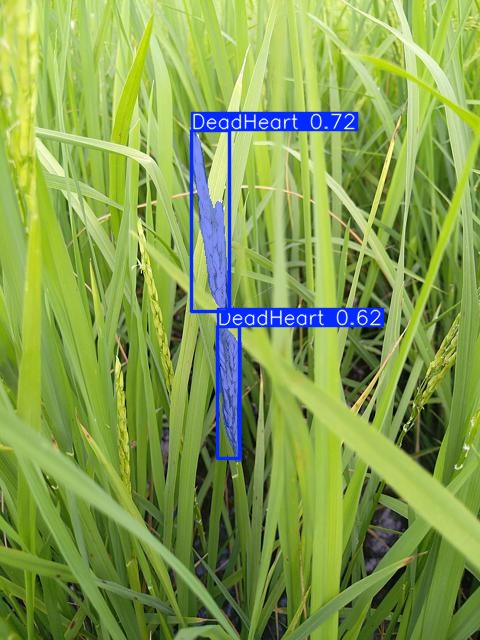

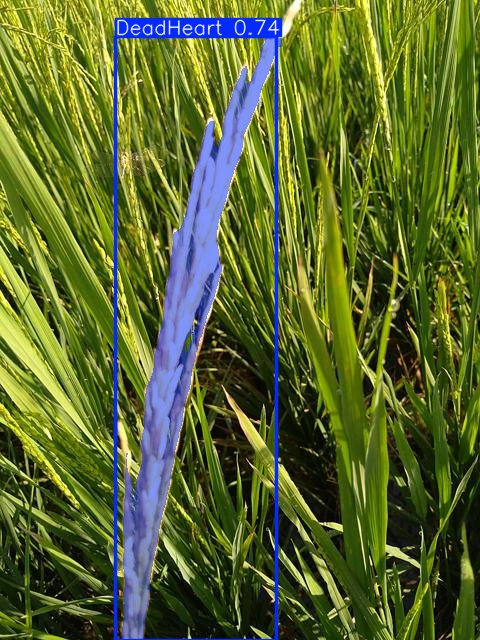

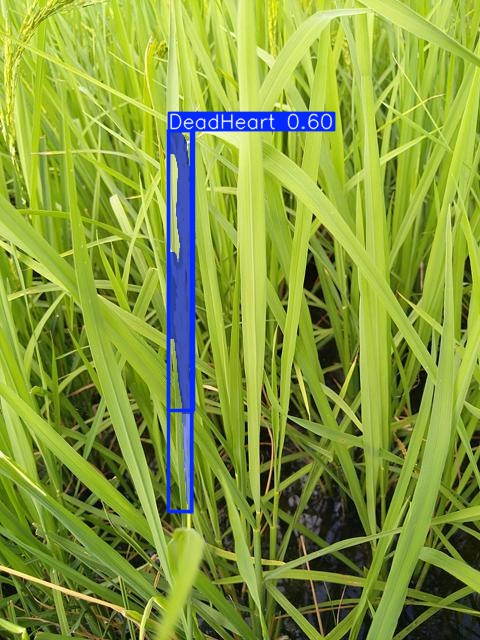

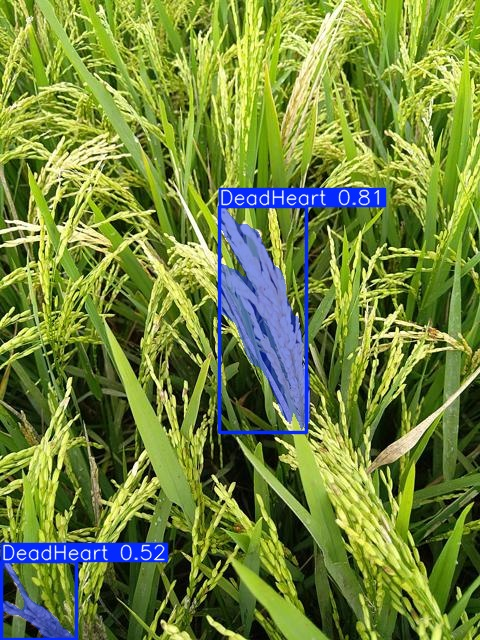

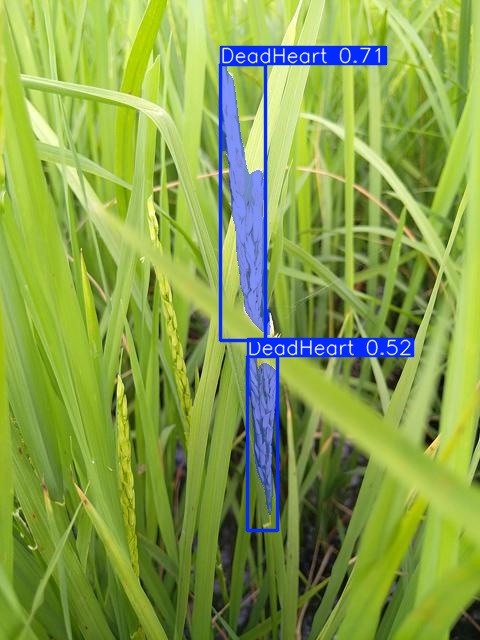

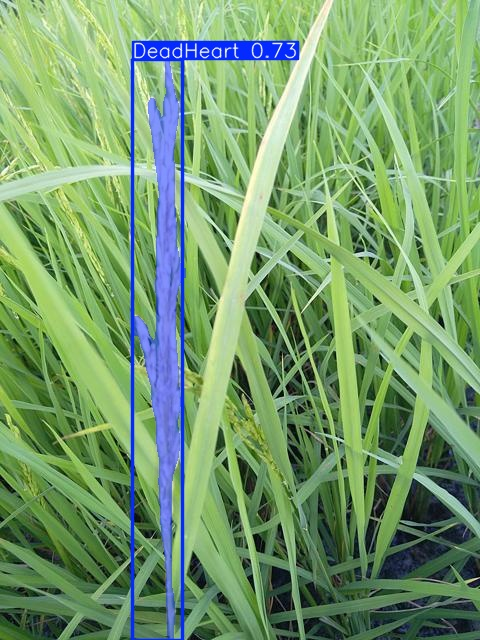

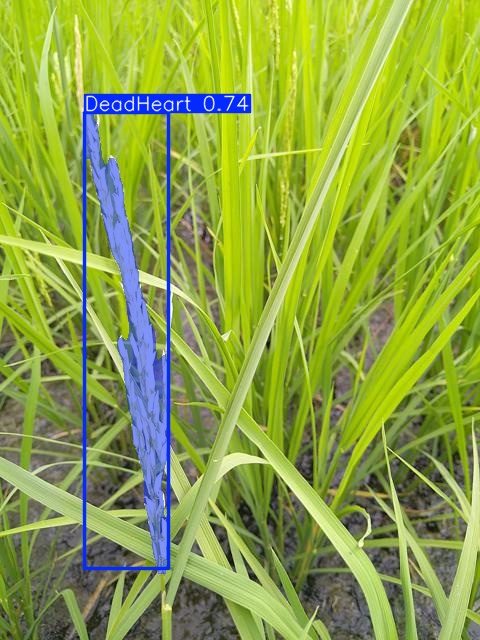

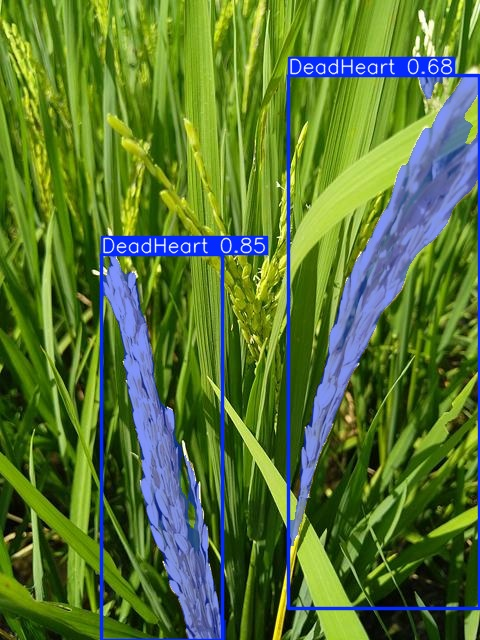

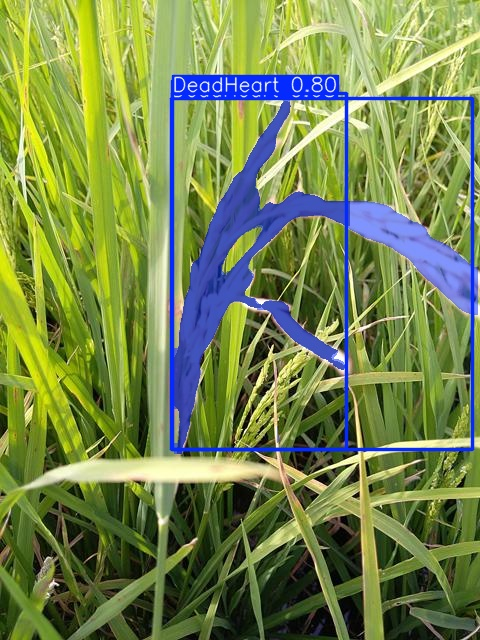

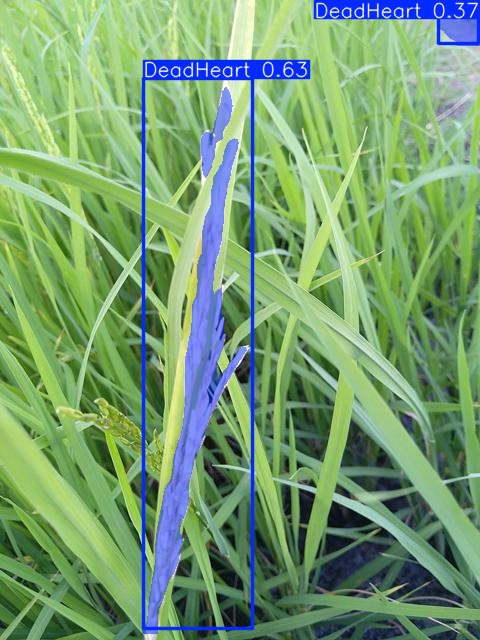

In [ ]:
from IPython.display import Image, display
import os

pred_dir = "/content/runs/segment/predict"

files = sorted(os.listdir(pred_dir))

for f in files[:10]:
    display(Image(filename=os.path.join(pred_dir, f)))

In [ ]:
import os
import shutil

deadheart_dir = "/content/deadheart_detected"
no_deadheart_dir = "/content/no_deadheart"

os.makedirs(deadheart_dir, exist_ok=True)
os.makedirs(no_deadheart_dir, exist_ok=True)

dh_count = 0
no_dh_count = 0

for r in results:
    image_path = r.path

    if r.boxes is not None and len(r.boxes) > 0:
        shutil.copy(image_path, deadheart_dir)
        dh_count += 1
    else:
        shutil.copy(image_path, no_deadheart_dir)
        no_dh_count += 1

print("Images WITH Dead Heart:", dh_count)
print("Images WITHOUT Dead Heart:", no_dh_count)


Images WITH Dead Heart: 1414
Images WITHOUT Dead Heart: 28


In [ ]:
results = model.predict(
    source="/content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart",
    conf=0.50,
    save=False
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100008.jpg: 640x480 2 DeadHearts, 19.0ms
image 2/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100015.jpg: 640x480 1 DeadHeart, 18.1ms
image 3/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100020.jpg: 640x480 1 DeadHeart, 19.9ms
image 4/1442 /content/drive/MyDrive/PaddyPanicleProject/datas

In [ ]:
import numpy as np

all_confidences = []

for r in results:
    if r.boxes is not None and len(r.boxes) > 0:
        confs = r.boxes.conf.cpu().numpy()
        all_confidences.extend(confs)

print("Total detections:", len(all_confidences))
print("Mean confidence:", np.mean(all_confidences))
print("Min confidence:", np.min(all_confidences))
print("Max confidence:", np.max(all_confidences))

Total detections: 1822
Mean confidence: 0.75586313
Min confidence: 0.5003321
Max confidence: 0.94962573


In [ ]:
!ls /content/runs/segment

predict


In [ ]:
# ── Auto-Label with your trained Dead Heart model ──
from ultralytics import YOLO
from pathlib import Path
import shutil, os

# 1. Load your best trained Dead Heart model
# model = YOLO("/content/runs/segment/train/weights/best.pt")  # adjust path to your best weights
model = YOLO("/content/drive/MyDrive/PaddyPanicleProject/results/deadheart_clean_s/weights/best.pt")

# 2. Point to ALL raw images (including already-annotated ones is fine)
RAW_IMAGES = "/content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart"

# 3. Run inference at LOW confidence to maximize recall
results = model.predict(
    source=RAW_IMAGES,
    conf=0.20,          # low threshold → catch more, prune later
    iou=0.5,
    retina_masks=True,
    save=False,
    save_txt=True,      # ← saves YOLO-seg format labels
    save_conf=False,
    project="/content/drive/MyDrive/PaddyPanicleProject/datasets/dead_heart_auto_labels",
    name="auto_run"
)

print("Auto-labeling complete!")
print("Labels saved to: /content/drive/MyDrive/PaddyPanicleProject/datasets/dead_heart_auto_labels/auto_run/labels/")



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100008.jpg: 640x480 2 DeadHearts, 13.6ms
image 2/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100015.jpg: 640x480 1 DeadHeart, 11.5ms
image 3/1442 /content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart/100020.jpg: 640x480 1 DeadHeart, 11.1ms
image 4/1442 /content/drive/MyDrive/PaddyPanicleProject/datas

In [18]:
# ── Copy matching images next to the auto-generated labels ──
import os
import shutil

# Where auto-label saved the .txt files
labels_dir = "/content/drive/MyDrive/PaddyPanicleProject/datasets/dead_heart_auto_labels/auto_run/labels"

# Where the original raw images live
raw_images_dir = "/content/drive/MyDrive/PaddyPanicleProject/datasets/raw/paddy_doctor_deadheart"

# Create an "images" folder next to "labels"
images_dir = labels_dir.replace("/labels", "/images")
os.makedirs(images_dir, exist_ok=True)

copied = 0
missing = 0

for label_file in os.listdir(labels_dir):
    if not label_file.endswith(".txt"):
        continue

    stem = os.path.splitext(label_file)[0]

    # Try common image extensions
    found = False
    for ext in [".jpg", ".jpeg", ".png"]:
        src = os.path.join(raw_images_dir, stem + ext)
        if os.path.exists(src):
            shutil.copy2(src, os.path.join(images_dir, stem + ext))
            copied += 1
            found = True
            break

    if not found:
        missing += 1

print(f"✅ Copied {copied} images into: {images_dir}")
if missing > 0:
    print(f"⚠️ {missing} labels had no matching image in raw folder")


✅ Copied 1417 images into: /content/drive/MyDrive/PaddyPanicleProject/datasets/dead_heart_auto_labels/auto_run/images


In [19]:
# Create labelmap for Roboflow
labels_dir = "/content/drive/MyDrive/PaddyPanicleProject/datasets/dead_heart_auto_labels/auto_run"

with open(os.path.join(labels_dir, "labelmap.txt"), "w") as f:
    f.write("Dead_Heart\n")

print("✅ labelmap.txt created!")


✅ labelmap.txt created!


# **Now with all the 1417 images of deadheart training**

In [20]:
from ultralytics import YOLO

model = YOLO("yolo11s-seg.pt")  # segmentation base

model.train(
    data="/content/drive/MyDrive/PaddyPanicleProject/datasets/DeadHeart_All_Images/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    project="/content/drive/MyDrive/PaddyPanicleProject/results",
    name="deadheart_all_1417_images_clean_s"
)

Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/PaddyPanicleProject/datasets/DeadHeart_All_Images/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=deadheart_all_1417_images_clean_s, nbs=64, nms=False, op

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c72d4a86930>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [1]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/PaddyPanicleProject/results/deadheart_all_1417_images_clean_s/weights/best.pt")
model_path = YOLO("/content/drive/MyDrive/PaddyPanicleProject/results/deadheart_all_1417_images_clean_s/weights/best.pt")

---
## 📊 Model Evaluation & Metrics

This section automatically evaluates the fully trained model on the validation set
and extracts the key performance metrics (Precision, Recall, mAP50, mAP50-95).
Use these standard metrics for your capstone project report.

Running full exhaustive validation suite...
Ultralytics 8.4.24 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s-seg summary (fused): 114 layers, 10,067,203 parameters, 0 gradients, 32.8 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 13.8±3.3 MB/s, size: 84.5 KB)
val: Scanning /content/drive/.shortcut-targets-by-id/1kLeaE77JygL_DGcYKmEqHoqmOfRCW_8A/PaddyPanicleProject/datasets/DeadHeart_All_Images/valid/labels.cache... 282 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 282/282 42.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 1.9it/s 9.3s
                   all        282        473      0.861      0.838      0.902      0.734      0.907        0.8       0.88      0.653
Speed: 3.5ms preprocess, 13.1ms inference, 0.0ms loss, 3.5ms postprocess per image
Results saved to /content/runs/segment/val2

══════════════════════════════════

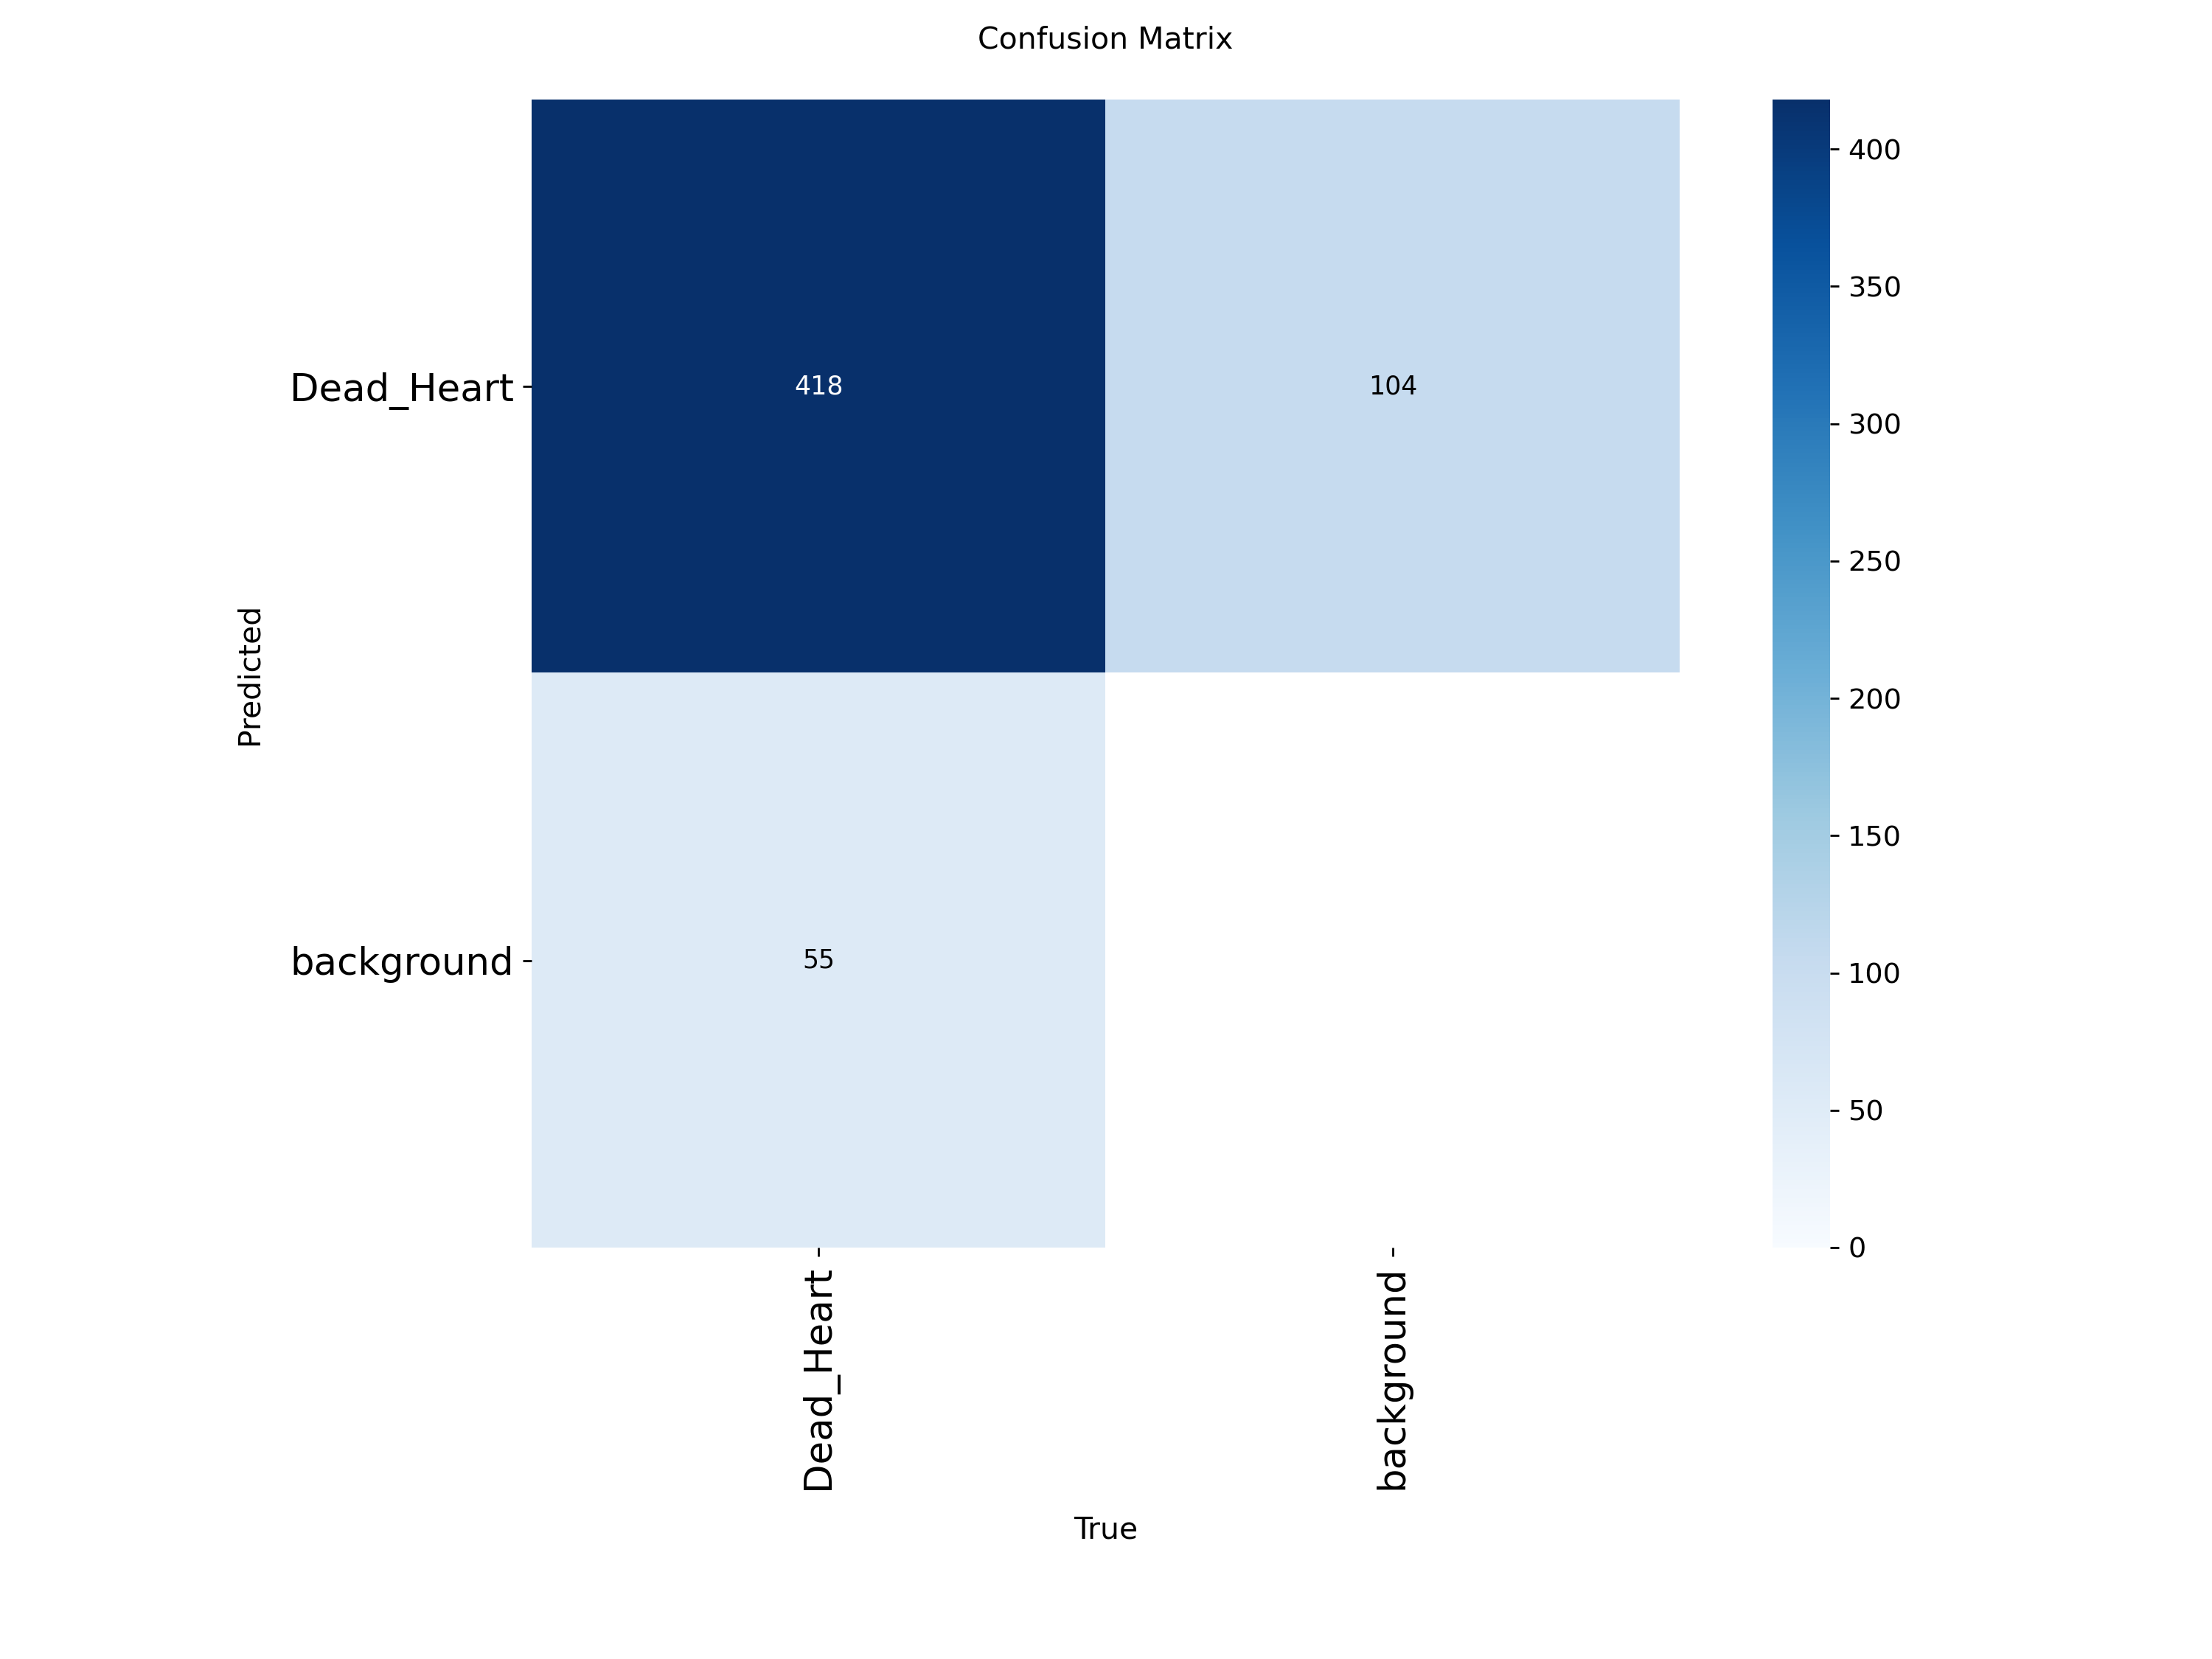


► confusion_matrix_normalized.png:


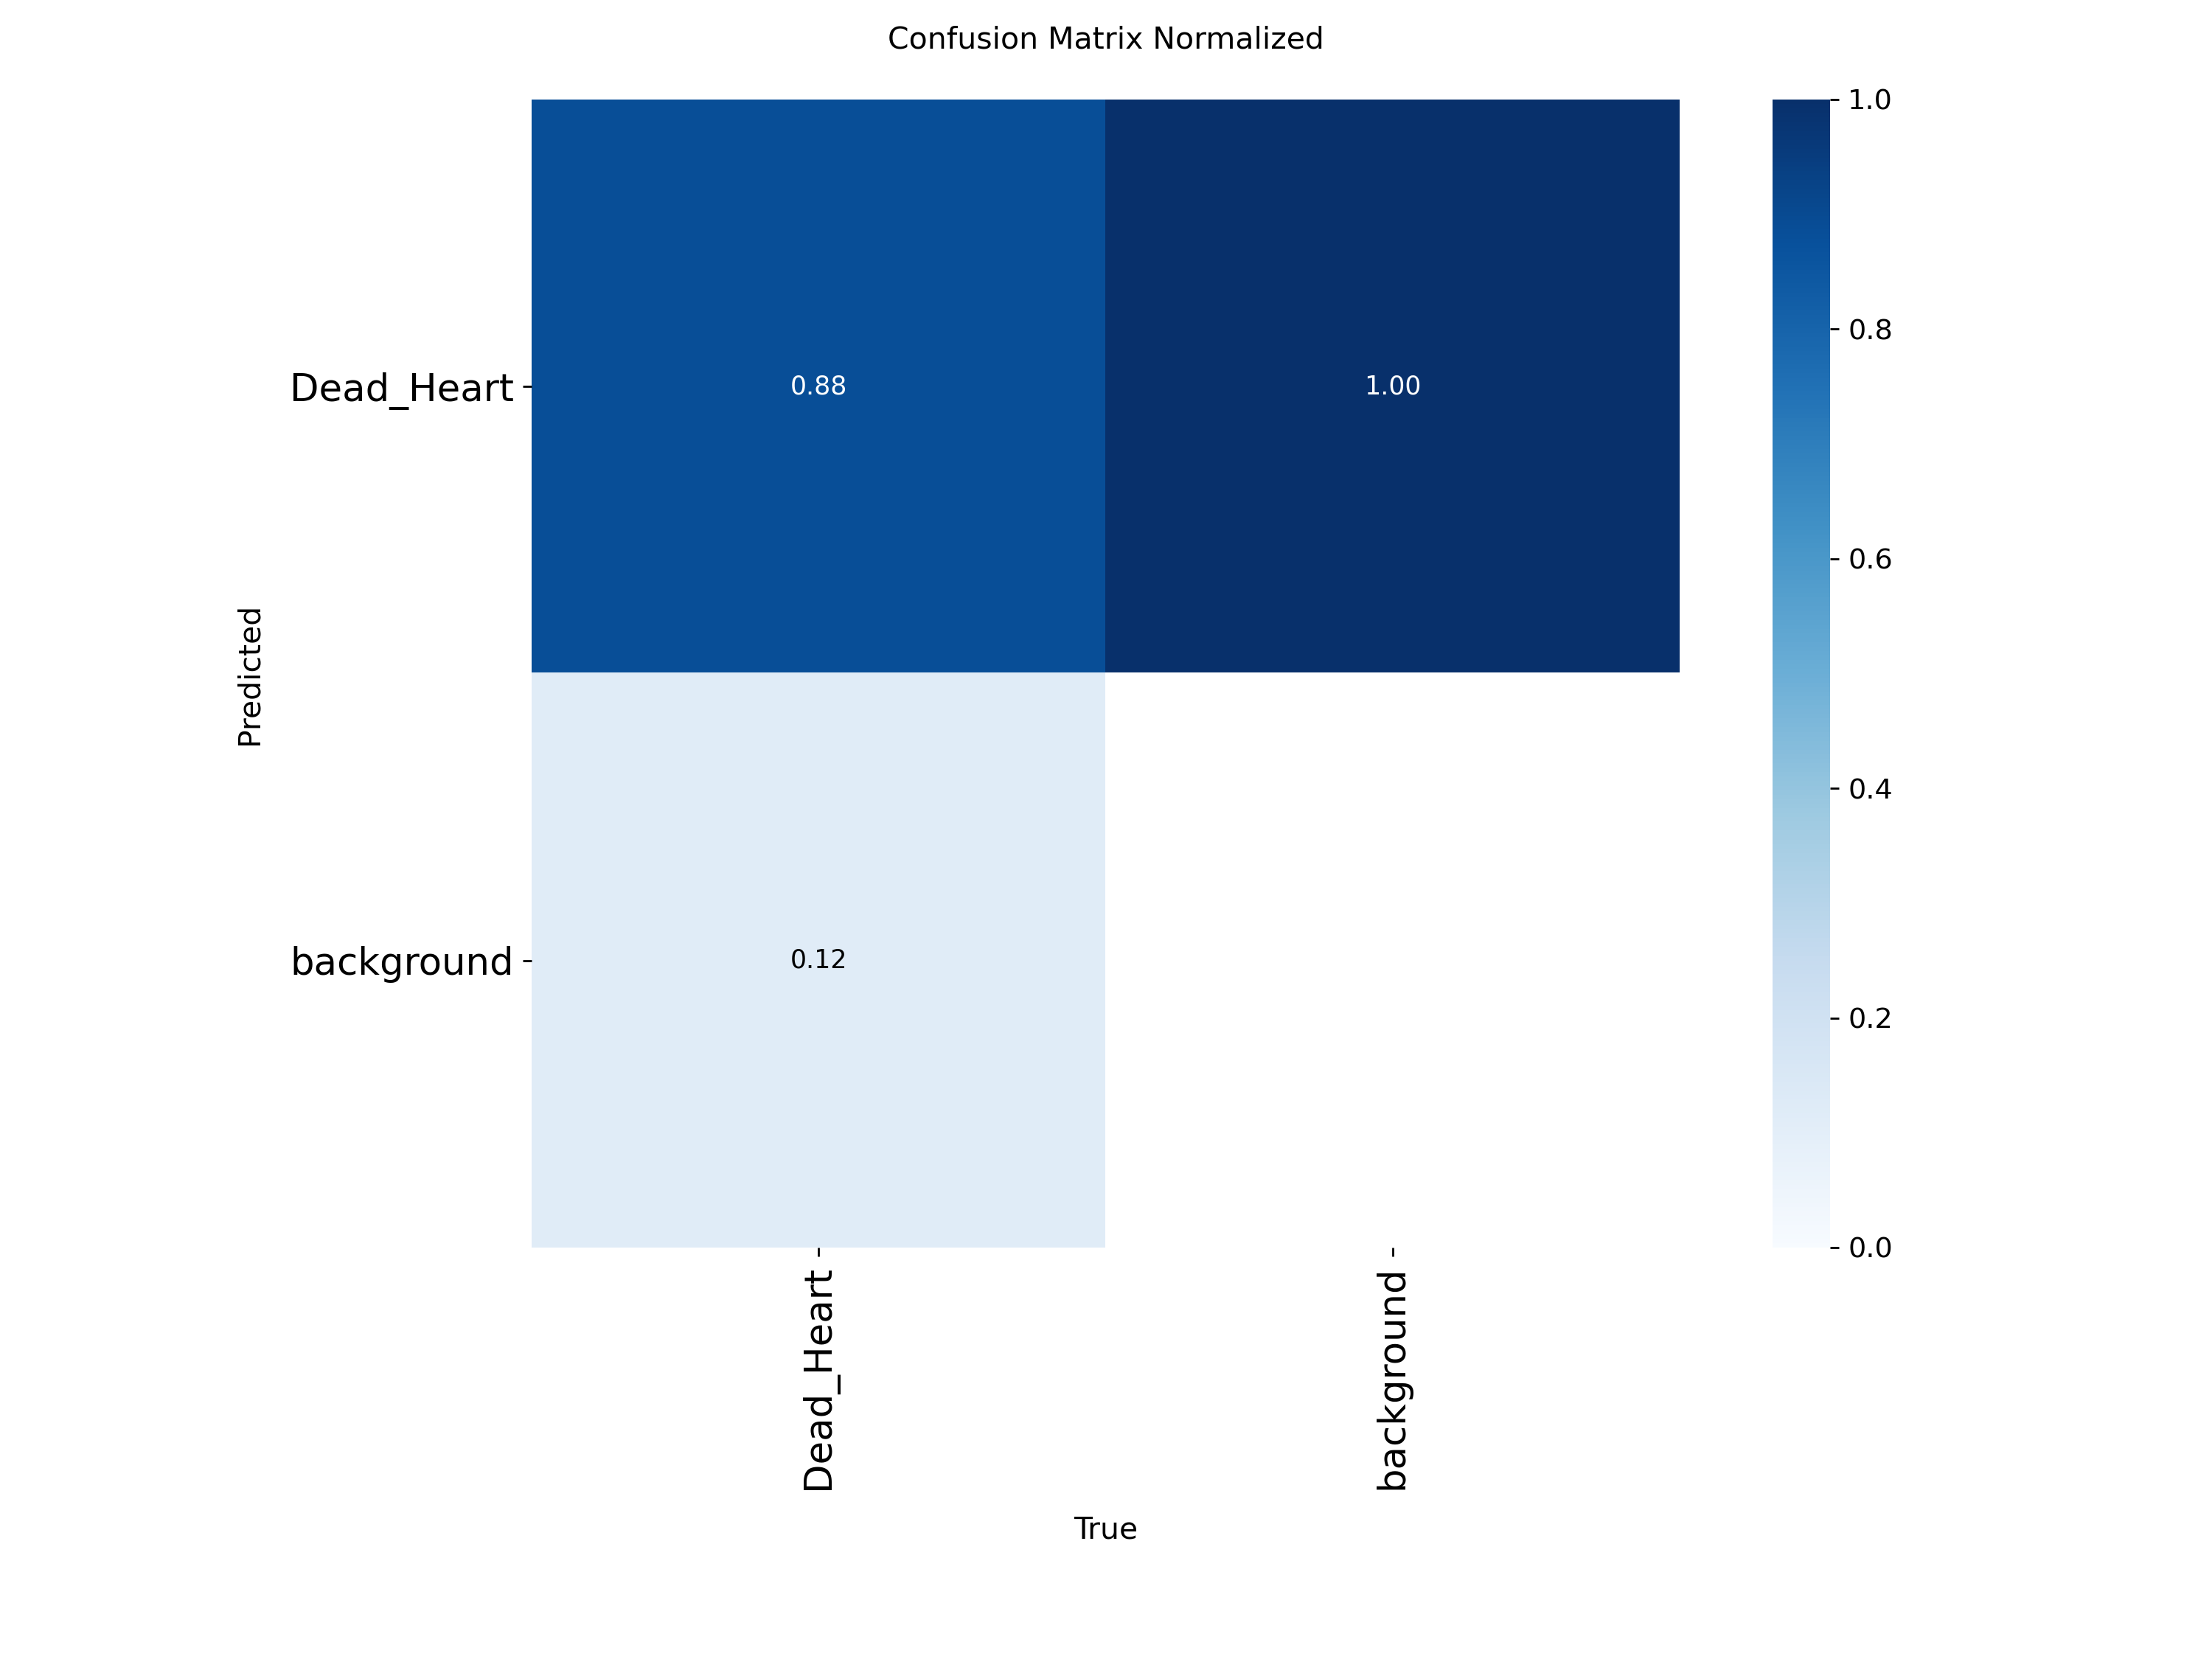

In [2]:
# ── EXTRACT EVERY SINGLE AVAILABLE METRIC, GRAPH, AND STATISTIC ──
import pandas as pd
from IPython.display import display, Image
import os

print("Running full exhaustive validation suite...")
# 1. Run validation engine
metrics = model.val()
res = metrics.results_dict
speed = metrics.speed

print("\n" + "═"*70)
print(f"   EXHAUSTIVE YOLOv11 PERFORMANCE MATRICES")
print("═"*70)

# 2. Calculate Standard Box Metrics
if 'metrics/precision(B)' in res:
    p_box = res['metrics/precision(B)']
    r_box = res['metrics/recall(B)']
    map50_box = res['metrics/mAP50(B)']
    map95_box = res['metrics/mAP50-95(B)']
    f1_box = 2 * (p_box * r_box) / (p_box + r_box) if (p_box + r_box) > 0 else 0

    print("  [BOUNDING BOX DETECTION]")
    print(f"  Precision (P)          : {p_box:.4f}  ({p_box*100:.2f}%)")
    print(f"  Recall (R)             : {r_box:.4f}  ({r_box*100:.2f}%)")
    print(f"  F1-Score               : {f1_box:.4f}  ({f1_box*100:.2f}%)")
    print(f"  mAP@50 (IoU=0.50)      : {map50_box:.4f}  ({map50_box*100:.2f}%)")
    print(f"  mAP@50-95 (Strict Avg) : {map95_box:.4f}  ({map95_box*100:.2f}%)")
    print("──────────────────────────────────────────────────────────────────────")

# 3. Calculate Segmentation Mask Metrics
if 'metrics/precision(M)' in res:
    p_mask = res['metrics/precision(M)']
    r_mask = res['metrics/recall(M)']
    map50_mask = res['metrics/mAP50(M)']
    map95_mask = res['metrics/mAP50-95(M)']
    f1_mask = 2 * (p_mask * r_mask) / (p_mask + r_mask) if (p_mask + r_mask) > 0 else 0

    print("\n  [SEGMENTATION MASKS]")
    print(f"  Mask Precision         : {p_mask:.4f}  ({p_mask*100:.2f}%)")
    print(f"  Mask Recall            : {r_mask:.4f}  ({r_mask*100:.2f}%)")
    print(f"  Mask F1-Score          : {f1_mask:.4f}  ({f1_mask*100:.2f}%)")
    print(f"  Mask mAP@50            : {map50_mask:.4f}  ({map50_mask*100:.2f}%)")
    print(f"  Mask mAP@50-95         : {map95_mask:.4f}  ({map95_mask*100:.2f}%)")
    print("──────────────────────────────────────────────────────────────────────")

# 4. Inference Speed Metrics
print("\n  [INFERENCE & PRE-PROCESSING SPEED (milliseconds/image)]")
print(f"  Pre-process Speed      : {speed.get('preprocess', 0.0):.2f} ms")
print(f"  Inference Speed        : {speed.get('inference', 0.0):.2f} ms")
print(f"  Post-process (NMS)     : {speed.get('postprocess', 0.0):.2f} ms")
print(f"  Total Time per Image   : {sum(speed.values()):.2f} ms")
print("──────────────────────────────────────────────────────────────────────")

# 5. The Raw Dictionary Dump (Fitness, Class Overlap, Loss, Everything Else)
print("\n  [ALL OTHER RAW INTERNAL METRICS]")
for key, value in res.items():
    if 'metrics/' not in key:  # already printed clearly above
        print(f"  {key:<22} : {value:.6f}")

print("\n" + "═"*70)
print("✅ All numerical metrics extracted.")

# 6. Auto-Display Graphical Metrics (Confusion Matrix, PR Curve, F1 Curve)
# Ultralytics saves these automatically to the active run directory (e.g. runs/detect/val)
val_dir = metrics.save_dir
graphs = ['confusion_matrix.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'PR_curve.png']
print("\nLoading YOLO validation graphics...")
for g in graphs:
    graph_path = os.path.join(val_dir, g)
    if os.path.exists(graph_path):
        print(f"\n► {g}:")
        display(Image(filename=graph_path, width=800))

## 🧪 Exhaustive Evaluation Block
The cell below forces the YOLO engine to calculate and dump **every single bounding box, segmentation mask, speed, and loss metric** stored internally, guaranteeing nothing is left behind.

Loading weights from: YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, 

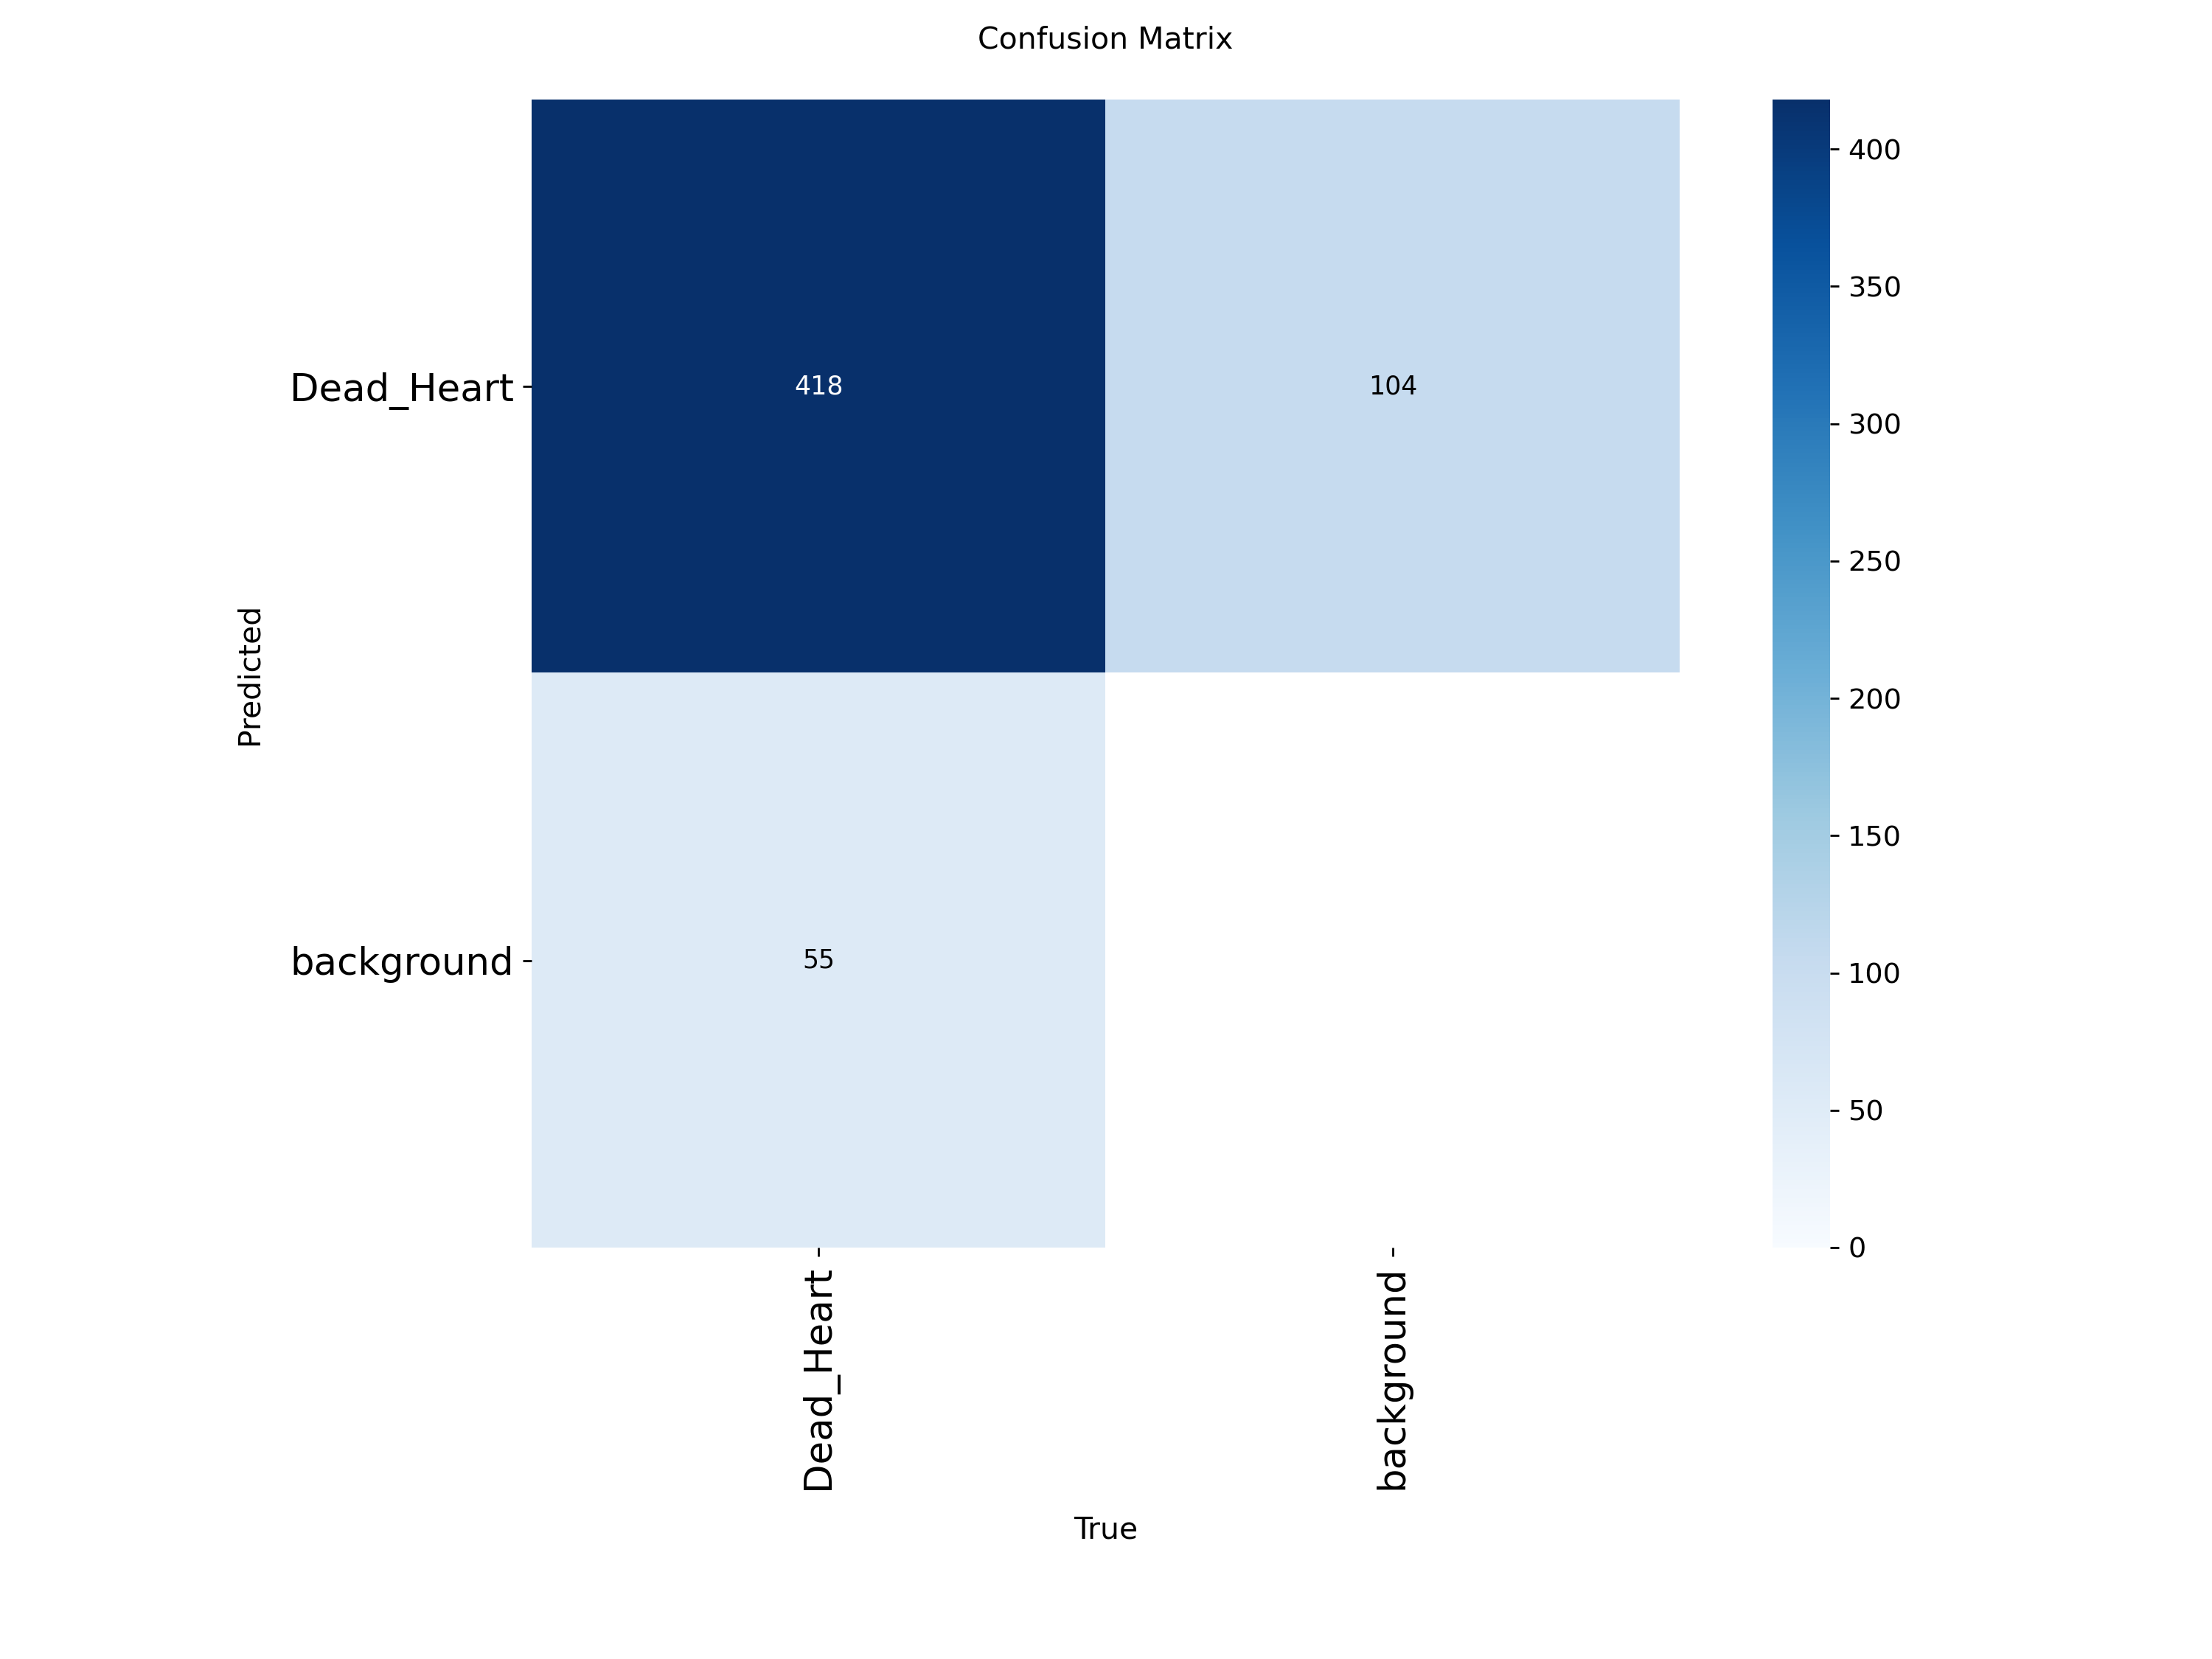


📈 Displaying confusion_matrix_normalized.png:


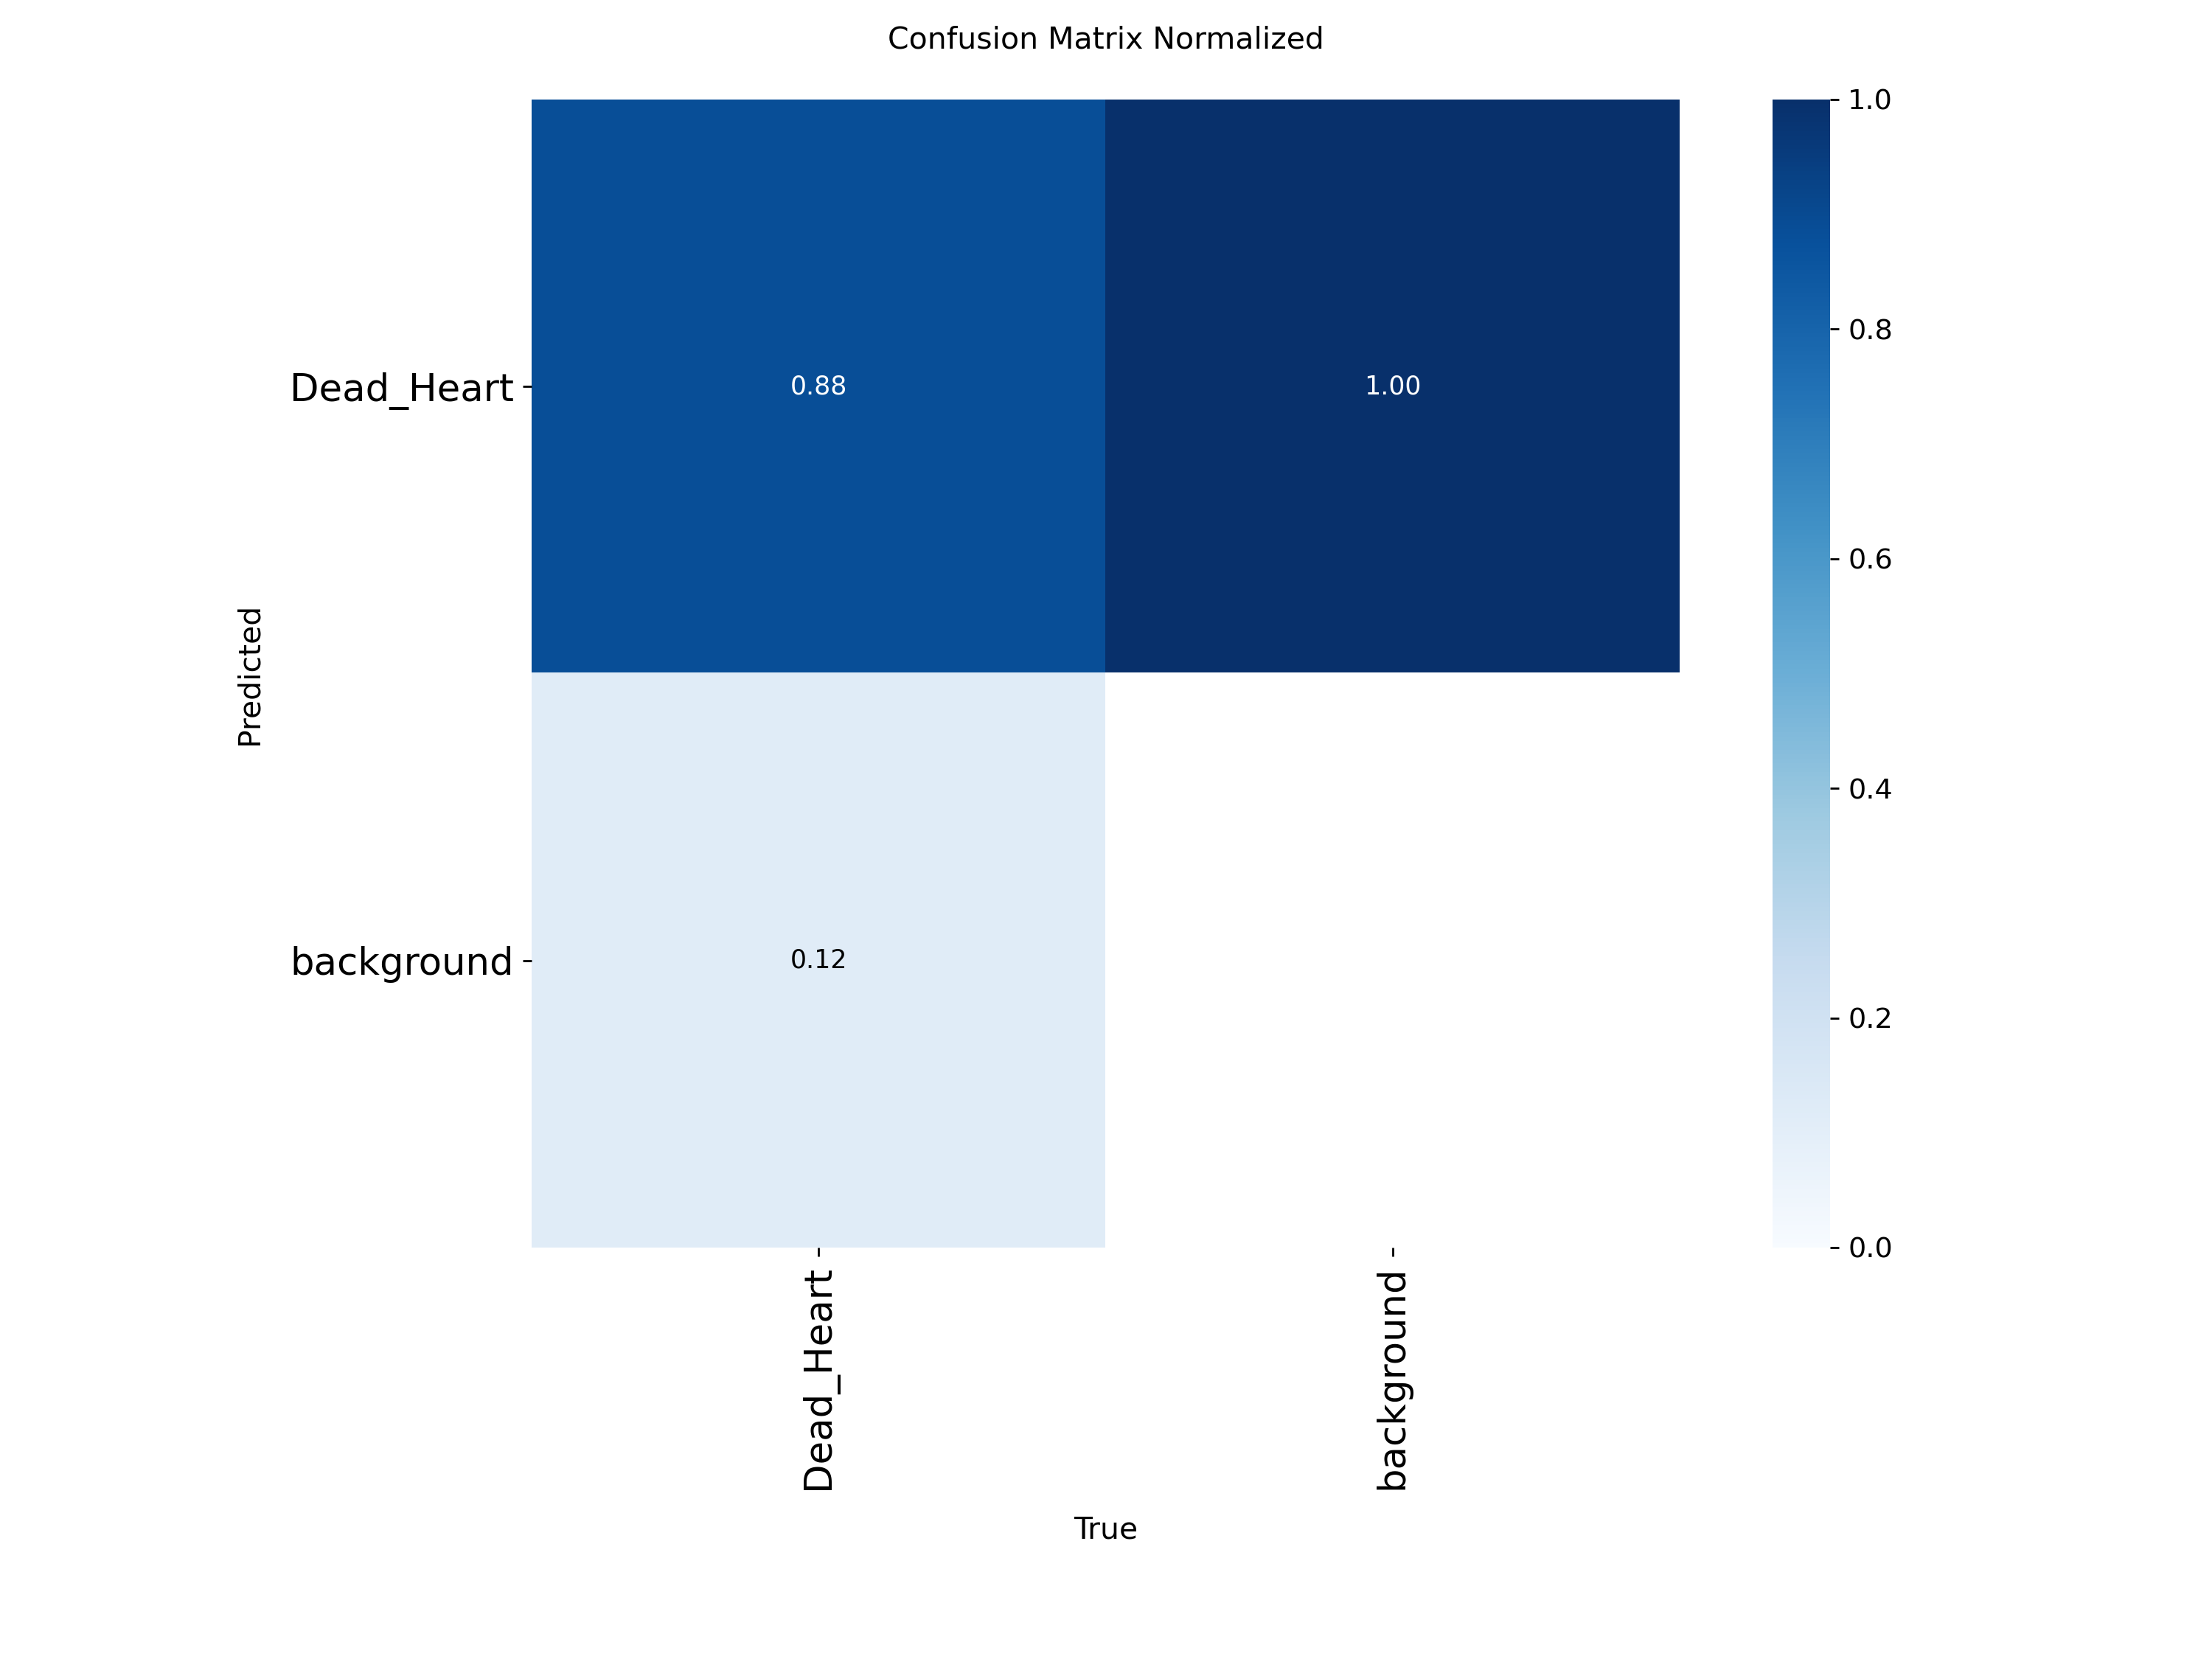

Graph not found: PR_curve.png
Graph not found: F1_curve.png

✅ Comprehensive Evaluation Complete.


In [3]:
# ── Exhaustive Model Evaluation & Metrics ──
from ultralytics import YOLO
import os
from IPython.display import Image, display

# Initialize the exact loaded model based on which notebook this is
# The path must be defined before this cell or explicitly provided
if 'model_path' not in locals():
    print("⚠️ Please define 'model_path' before running this cell.")
else:
    print(f"Loading weights from: {model_path}")
    eval_model = YOLO(model_path)

    print("\n\n=====================================================================")
    print("                     STARTING EXHAUSTIVE EVALUATION                  ")
    print("=====================================================================\n")

    # Run absolute, no-compromise validation
    metrics = eval_model.val()

    # ---------------------------------------------------------
    # 1. CORE BOUNDING BOX METRICS
    # ---------------------------------------------------------
    print("\n📊 --- CORE BOUNDING BOX METRICS ---")
    print(f"Box Precision (P)      : {metrics.box.map50:^10.4f}  (mAP@50)")
    print(f"Box mAP (50-95)        : {metrics.box.map:^10.4f}  (Strict map@50-95)")
    r_val = metrics.box.mr if hasattr(metrics.box, 'mr') else 'N/A'
    if hasattr(r_val, '__len__') and not isinstance(r_val, float): r_val = r_val[-1]
    print(f"Box Recall (R)         : {r_val:^10.4f}  (Mean Recall)" if isinstance(r_val, float) else f"Box Recall (R)         : {r_val}")

    # ---------------------------------------------------------
    # 2. CORE SEGMENTATION MASK METRICS
    # ---------------------------------------------------------
    if hasattr(metrics, 'seg'):
        print("\n🧬 --- INSTANCE SEGMENTATION MASK METRICS ---")
        print(f"Mask Precision (P)     : {metrics.seg.map50:^10.4f}  (mAP@50)")
        print(f"Mask mAP (50-95)       : {metrics.seg.map:^10.4f}  (Strict map@50-95)")

    # ---------------------------------------------------------
    # 3. SPEED & TIMING METRICS (Inference Time)
    # ---------------------------------------------------------
    print("\n⚡ --- HARDWARE SPEED & INFERENCE METRICS ---")
    if hasattr(metrics, 'speed'):
        preprocess = metrics.speed.get('preprocess', 0.0)
        inference = metrics.speed.get('inference', 0.0)
        postprocess = metrics.speed.get('postprocess', 0.0)
        total_time = preprocess + inference + postprocess
        print(f"Pre-processing time    : {preprocess:.2f} ms per image")
        print(f"Inference time         : {inference:.2f} ms per image")
        print(f"Post-processing (NMS)  : {postprocess:.2f} ms per image")
        print(f"Total time per image   : {total_time:.2f} ms")

    # ---------------------------------------------------------
    # 4. RAW DICTIONARY DUMP (Loss & Internal params)
    # ---------------------------------------------------------
    print("\n🗄️ --- INTERNAL YOLO RAW DICTIONARY DUMP ---")
    for key, value in metrics.results_dict.items():
        if isinstance(value, float):
            print(f"{key:<30} : {value:.4f}")
        else:
            print(f"{key:<30} : {value}")

    # ---------------------------------------------------------
    # 5. GRAPHICAL AUTO-LOADER (Retrieving YOLO plots)
    # ---------------------------------------------------------
    print("\n\n=====================================================================")
    print("                     EVALUATION GRAPHS & PLOTS                       ")
    print("=====================================================================\n")

    latest_val_dir = metrics.save_dir if hasattr(metrics, 'save_dir') else None

    if latest_val_dir and os.path.exists(latest_val_dir):
        print(f"Searching for graphs in: {latest_val_dir}\n")
        graph_files = [
            'confusion_matrix.png',
            'confusion_matrix_normalized.png',
            'PR_curve.png',
            'F1_curve.png'
        ]

        for g in graph_files:
            graph_path = os.path.join(latest_val_dir, g)
            if os.path.exists(graph_path):
                print(f"\n📈 Displaying {g}:")
                display(Image(filename=graph_path, width=800))
            else:
                print(f"Graph not found: {g}")
    else:
        print("Could not locate the validation save directory to display graphs.")

print("\n✅ Comprehensive Evaluation Complete.")